# 16 - Step 6: models over the labels, and SHAP

Notebook 15 was step 5: it decided what "good" means. Four self-labelled targets, all standing in an
origin month `t` and looking forward. This notebook is step 6: try to predict them, measure whether it
worked, explain the models with SHAP, and score the live month into an actual ranked list.

**Why I am running this now rather than waiting.** There is a Charges API harvest running on my machine
that will add lender identity (which bank holds each charge, roughly 7.8% coverage so far) and, with it,
the real switching/attrition target that the bulk file cannot see. It is tempting to wait for it. But
training on today's features gives a baseline, and that baseline is the only thing that can ever tell me
whether the harvest was worth twenty-four hours of wall clock. Out-of-time AUC before versus after is a
clean measurement. Skip the baseline and the harvest becomes an act of faith. It is the same A/B design
I already set up for strict versus extended contracts.

So everything below is written to make that later re-run nearly free:

- the feature list is `targets.FEATURE_COLS`, never a copy of it, so new columns arrive by themselves;
- I iterate `targets.TARGETS` rather than writing four literals, so a fifth target appears on its own;
- categoricals go through `targets.CATEGORICAL_COLS` (the lender work adds at least one, `primary_lender_group`);
- the origin grid for each target is read **off that target's own partitions on disk**, not from a shared
  assumption, because a switching target will sit on a different base population ("has an outstanding
  Lloyds charge at `t`") that is much smaller than the "Active at `t`" the current four share.

And one thing I am deliberately *not* doing: **no hyperparameter tuning**. Tuning against a feature set
that is about to gain columns is wasted effort. Tune once, at the end, on the final matrix.

## Setup

In [1]:
import os
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))
# Every default path in src/ is repo-root relative, so work from there.
os.chdir(REPO_ROOT)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from src.features import contracts, panel
from src.models import targets, train

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

print(f"{len(targets.FEATURE_COLS)} features, {len(targets.TARGETS)} targets")
print(f"categoricals: {targets.CATEGORICAL_COLS}")

/home/viklin/repos/lloyds-commercial-banking-intelligence-2026/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


41 features, 4 targets
categoricals: ['sector', 'segment']


## The split, and why it is not `train_test_split`

Sneha's baseline notebook uses `train_test_split(X, y, test_size=0.25, stratify=y)`. That is the right
call for the cross-sectional problem she set up and the wrong one here, in two independent ways.

**Company leakage.** Each company appears in up to 33 monthly rows and at every quarterly origin. A random
split puts some of those rows in train and the rest in test, so the model can memorise the company instead
of learning the pattern. The test score comes out flattering and means nothing.

**Time leakage.** A random split mixes 2026 rows into training while testing on 2024. The model gets to
see the future, which in production it never does.

Either one alone invalidates the evaluation. So: **train on early origins, test on late ones**, with an
**embargo** in between.

The embargo is the part that is easy to skip. A training row at origin `t` carries a label that resolves
over `t+1 ... t+H`. If the first test origin sits inside that window, the model was trained on the answer
to its own exam. So I drop every origin where `first_test - t < H` months. At the boundary, where
`first_test - t == H` exactly, the training label resolves in the test origin's *feature* month, which is
data the model is handed anyway, and the test labels only start at `first_test + 1`. That is clean, so the
rule is a gap of **at least** `H`.

In [2]:
splits = {t: train.split_origins(t) for t in targets.TARGETS}
for s in splits.values():
    print(s.describe())
    print()

lending (H=3m)
  train   : 2024-10, 2025-01, 2025-04, 2025-07, 2025-10
  embargo : -  (dropped, labels resolve inside test)
  test    : 2026-01, 2026-04
  early-origin filter applied: True

insolvency (H=6m)
  train   : 2024-10, 2025-01, 2025-04
  embargo : 2025-07  (dropped, labels resolve inside test)
  test    : 2025-10, 2026-01
  early-origin filter applied: True

voluntary_exit (H=6m)
  train   : 2024-10, 2025-01, 2025-04
  embargo : 2025-07  (dropped, labels resolve inside test)
  test    : 2025-10, 2026-01
  early-origin filter applied: True

growth (H=12m)
  train   : 2023-10, 2024-01, 2024-04
  embargo : 2024-07, 2024-10, 2025-01  (dropped, labels resolve inside test)
  test    : 2025-04, 2025-07
  early-origin filter applied: False



Three things to read off that.

**Lending loses nothing to the embargo.** Its horizon is 3 months and the origins are quarterly, so
consecutive origins are already exactly `H` apart. That was the point of quarterly origins in step 5, and
it is why lending gets five training origins where insolvency gets three.

**Growth had to give up the early-origin filter.** `targets.FIRST_FULL_ORIGIN` (2024-10) is the first
month where the 12-month deltas are actually formed rather than NULL for calendar reasons. I would rather
train past it, because that missingness pattern lands entirely in train and never in test, and it is
exactly the sort of artefact a tree will happily split on and then be unable to use. But growth has a
12-month horizon, so the embargo eats three whole origins, and honouring the filter as well would leave it
with none. `split_origins` drops the filter automatically when it would leave fewer than three training
origins, and records that it did. Growth therefore trains on 2023-10 to 2024-04 where the 12m deltas are
partly NULL. Worth remembering when reading its numbers.

**Voluntary exit and insolvency share a grid but not a difficulty.** Same horizon, same origins, wildly
different base rates (about 7.5% against about 0.33%).

## precision@N has to be measured on the unsampled population

This is the subtlest thing in the notebook and it took me a second pass to get right.

Step 5 wrote the modelling matrix with **negatives downsampled to roughly 10x the positives**, which is
what makes a 0.33% label trainable at all. But that matrix is no longer the population the model would
actually rank. If I compute precision@100 on it, I am asking "of the top 100 out of a pile I already
enriched 30-fold with positives, how many were right", and the answer is inflated by roughly that factor.

ROC-AUC survives negative downsampling, because it only compares positives against negatives pairwise and
downsampling negatives uniformly does not change that ordering in expectation. **PR-AUC and precision@N do
not survive it**, and precision@N is the headline metric here: a relationship manager works a finite call
list, so "of our top 500 picks, how many were right" is the question that matters. AUC over 1.4 million
companies does not answer it.

So the test origins get rebuilt with no downsampling at all. `targets.build_matrix` caps the negative keep
rate at 1.0, so a large enough `neg_ratio` simply keeps everything, and I did not have to write a second
query to get there.

In [3]:
eval_summary = pd.concat([
    train.build_eval_matrix(t, splits[t].test, threads=6)
    for t in targets.TARGETS
], ignore_index=True)
eval_summary

,target,horizon_m,origin_month,rows,positives,sampled_rate,neg_keep_rate
0,lending,3,2026-01-01,1385254,3568.0,0.002576,1.0
1,lending,3,2026-04-01,1397337,3976.0,0.002845,1.0
2,insolvency,6,2025-10-01,1394358,4570.0,0.003277,1.0
3,insolvency,6,2026-01-01,1385254,4586.0,0.003311,1.0
4,voluntary_exit,6,2025-10-01,1394358,114834.0,0.082356,1.0
5,voluntary_exit,6,2026-01-01,1385254,99963.0,0.072162,1.0
6,growth,12,2025-04-01,907568,19247.0,0.021207,1.0
7,growth,12,2025-07-01,909551,19586.0,0.021534,1.0


`sampled_rate` there is now the **true** base rate, and every one of them lands where notebook 15 measured
it: lending 0.26-0.28%, insolvency 0.33%, voluntary exit 7.2-8.2%, growth 2.1%. That is the same base-rate
assertion from step 5, arriving a second time by a different route, which is a reassuring thing for it to do.

## Train

Two models per target. **LightGBM** is the real one. **Logistic regression** is an interpretable floor, and
it is worth the extra twenty minutes for two reasons: if the boosting cannot clearly beat a regularised
linear model on the same features then it is not earning its complexity and I should say so, and its signed
coefficients are an independent check on the SHAP directions. If SHAP says more charges means more distress
and the coefficient says the opposite, one of them is wrong.

Two implementation notes.

**Early stopping uses a company-grouped slice of the training rows, never the test set.** Stopping on the
test set is tuning on the exam, just more politely. Grouped rather than random for the same leakage reason
as the main split.

**`n_jobs=6`, not `-1`.** This is not a tuning knob, it is a workaround, and it cost me an hour so it is
going in the notebook. Under WSL2 `n_jobs=-1` reads 22 logical cores and then spends essentially all its
time in thread contention: 50 boosting rounds on the 165k-row insolvency matrix took **98 seconds** at
`n_jobs=-1` and **0.9 seconds** at `n_jobs=8`. Two orders of magnitude, identical result.

In [4]:
%%time
results = {t: train.run_target(t) for t in targets.TARGETS}

/home/viklin/repos/lloyds-commercial-banking-intelligence-2026/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: ['d_charges_12m' 'd_outstanding_12m' 'd_satisfied_12m'
 'debt_ratio_trend_12m' 'segment_upgraded_12m' 'segment_downgraded_12m'
 'sic_changed_12m' 'name_changed_12m' 'postcode_changed_12m']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


/home/viklin/repos/lloyds-commercial-banking-intelligence-2026/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: ['d_charges_12m' 'd_outstanding_12m' 'd_satisfied_12m'
 'debt_ratio_trend_12m' 'segment_upgraded_12m' 'segment_downgraded_12m'
 'sic_changed_12m' 'name_changed_12m' 'postcode_changed_12m']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


CPU times: user 19min 19s, sys: 26.4 s, total: 19min 45s
Wall time: 3min 26s


In [5]:
overview = pd.DataFrame([
    {
        "target": r["target"],
        "H (m)": r["horizon_m"],
        "train rows": r["train_rows"],
        "train pos": r["train_positives"],
        "test rows": r["metrics"]["lightgbm"]["n"],
        "test base rate": r["metrics"]["lightgbm"]["base_rate"],
        "best iter": r["best_iteration"],
    }
    for r in results.values()
])
overview.style.format({"train rows": "{:,}", "train pos": "{:,}",
                       "test rows": "{:,}", "test base rate": "{:.3%}"})

,target,H (m),train rows,train pos,test rows,test base rate,best iter
0,lending,3,"214,708","19,624","2,782,591",0.271%,143
1,insolvency,6,"165,674","15,022","2,779,612",0.329%,150
2,voluntary_exit,6,"3,779,912","343,699","2,779,612",7.728%,1106
3,growth,12,"610,789","55,564","1,817,119",2.137%,245


## Out-of-time results

In [6]:
rows = []
for r in results.values():
    for model, m in r["metrics"].items():
        rows.append({"target": r["target"], "model": model, "base_rate": m["base_rate"],
                     "roc_auc": m["roc_auc"], "pr_auc": m["pr_auc"],
                     **{f"P@{n}": m[f"precision_at_{n}"] for n in train.TOP_N},
                     **{f"lift@{n}": m[f"lift_at_{n}"] for n in train.TOP_N}})
scores = pd.DataFrame(rows)
scores.style.format({"base_rate": "{:.3%}", "roc_auc": "{:.4f}", "pr_auc": "{:.4f}",
                     **{f"P@{n}": "{:.1%}" for n in train.TOP_N},
                     **{f"lift@{n}": "{:.0f}x" for n in train.TOP_N}})

,target,model,base_rate,roc_auc,pr_auc,P@100,P@500,P@1000,lift@100,lift@500,lift@1000
0,lending,lightgbm,0.271%,0.8767,0.0567,55.0%,28.2%,22.2%,203x,104x,82x
1,lending,logistic,0.271%,0.8615,0.0403,18.0%,15.0%,14.0%,66x,55x,52x
2,insolvency,lightgbm,0.329%,0.7615,0.0169,19.0%,12.2%,11.3%,58x,37x,34x
3,insolvency,logistic,0.329%,0.7324,0.0119,3.0%,5.8%,5.9%,9x,18x,18x
4,voluntary_exit,lightgbm,7.728%,0.7929,0.3512,83.0%,84.8%,85.5%,11x,11x,11x
5,voluntary_exit,logistic,7.728%,0.7704,0.3104,6.0%,29.6%,42.6%,1x,4x,6x
6,growth,lightgbm,2.137%,0.7620,0.0578,22.0%,20.2%,17.5%,10x,9x,8x
7,growth,logistic,2.137%,0.7290,0.0468,7.0%,9.8%,12.7%,3x,5x,6x


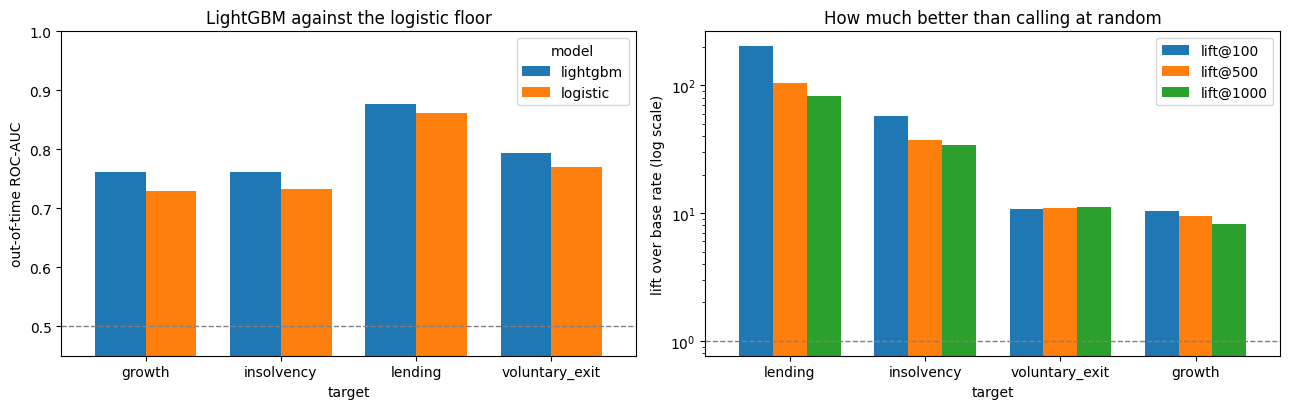

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
piv_auc = scores.pivot(index="target", columns="model", values="roc_auc")
piv_auc.plot.bar(ax=axes[0], rot=0, width=0.75)
axes[0].axhline(0.5, color="grey", ls="--", lw=1)
axes[0].set_ylim(0.45, 1.0)
axes[0].set_ylabel("out-of-time ROC-AUC")
axes[0].set_title("LightGBM against the logistic floor")

piv_lift = scores[scores.model == "lightgbm"].set_index("target")[[f"lift@{n}" for n in train.TOP_N]]
piv_lift.plot.bar(ax=axes[1], rot=0, width=0.75, logy=True)
axes[1].axhline(1, color="grey", ls="--", lw=1)
axes[1].set_ylabel("lift over base rate (log scale)")
axes[1].set_title("How much better than calling at random")
plt.tight_layout()
plt.show()

## Recalibration

Downsampling negatives at rate `r` multiplies the odds by `1/r`, so every predicted probability comes out
inflated by roughly 30x. Ranking survives that perfectly, because it is a monotone transform. The numbers
do not, and "this company has a 12% chance of insolvency" is a lie until it is corrected.

The correction is one line: `odds_true = odds_sampled * r`. Step 5 carried `neg_keep_rate` along on every
row precisely so step 6 could undo its own sampling without having to remember anything.

The check below is that the mean recalibrated prediction lands on the true base rate of the test
population. It is the cheapest possible test that the correction is the right way round, and getting it
backwards would be an easy mistake to not notice.

In [8]:
calib = pd.DataFrame([
    {"target": t, **r["calibration"]} for t, r in results.items()
])
calib["raw_inflation"] = calib["mean_pred_raw"] / calib["test_base_rate"]
calib["recal_ratio"] = calib["mean_pred_recalibrated"] / calib["test_base_rate"]
calib.style.format({"train_neg_keep_rate": "{:.4f}", "mean_pred_raw": "{:.4%}",
                    "mean_pred_recalibrated": "{:.4%}", "test_base_rate": "{:.4%}",
                    "raw_inflation": "{:.1f}x", "recal_ratio": "{:.2f}x"})

,target,train_neg_keep_rate,mean_pred_raw,mean_pred_recalibrated,test_base_rate,raw_inflation,recal_ratio
0,lending,0.0285,6.1337%,0.3008%,0.2711%,22.6x,1.11x
1,insolvency,0.0366,8.0005%,0.3635%,0.3294%,24.3x,1.10x
2,voluntary_exit,0.9000,8.7993%,8.1397%,7.7276%,1.1x,1.05x
3,growth,0.2112,8.6942%,2.1149%,2.1371%,4.1x,0.99x


## Secondary check: GroupKFold by company

Out-of-time is the primary split because it mirrors production. Grouped CV ignores time on purpose, and the
comparison between the two is the informative part: if grouped CV is much the better of the two, the model
has learned something about this particular period that will not survive into the next one. If they agree,
it generalises.

Row-capped at two million, because the point is a comparison and not a better estimate, and the
voluntary-exit matrix is twelve million rows.

In [9]:
%%time
cv = pd.DataFrame([train.grouped_cv_auc(t) for t in targets.TARGETS])
cv["oot_roc_auc"] = cv["target"].map(lambda t: results[t]["metrics"]["lightgbm"]["roc_auc"])
cv["gap"] = cv["mean_roc_auc"] - cv["oot_roc_auc"]
cv[["target", "rows", "mean_roc_auc", "oot_roc_auc", "gap"]].style.format(
    {"rows": "{:,}", "mean_roc_auc": "{:.4f}", "oot_roc_auc": "{:.4f}", "gap": "{:+.4f}"})

CPU times: user 12min 36s, sys: 16.9 s, total: 12min 53s
Wall time: 2min 55s


,target,rows,mean_roc_auc,oot_roc_auc,gap
0,lending,"457,941",0.8809,0.8767,+0.0043
1,insolvency,"520,142",0.7694,0.7615,+0.0078
2,voluntary_exit,"2,000,000",0.8142,0.7929,+0.0213
3,growth,"1,657,611",0.7747,0.7620,+0.0126


## SHAP

`TreeExplainer`, which is **exact** for tree models rather than an approximation, on a stratified 100k
subsample of the test population. Stratified matters here: a plain 100k draw from a 0.33% base rate holds
about 330 positives, and the summary plot would end up describing the negatives almost exclusively.

A note on why SHAP and not LIME, since it came up. LIME is not a model or a training framework, it is a
post-hoc explainer, the same category of tool as SHAP; you do not "train on LIME". And for trees SHAP is
strictly better: exact rather than a local surrogate, stable across re-runs rather than resampled (which
matters a lot when the explanation is going in front of a relationship manager), and additive, so the
values sum to the prediction. That last property is what lets a composite index be decomposed into
contributions at all.

In [10]:
%%time
explanations = {}
for t, r in results.items():
    Xs, ys = train.shap_sample(r["_X_test"], r["_y_test"])
    sv = shap.TreeExplainer(r["_models"]["lightgbm"]).shap_values(Xs)
    sv = sv[1] if isinstance(sv, list) else sv
    explanations[t] = {"X": Xs, "y": ys, "shap": sv,
                       "importance": train.shap_importance(sv, Xs)}
    print(f"{t}: {sv.shape[0]:,} rows x {sv.shape[1]} features")

/home/viklin/repos/lloyds-commercial-banking-intelligence-2026/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


lending: 100,000 rows x 41 features


/home/viklin/repos/lloyds-commercial-banking-intelligence-2026/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


insolvency: 100,000 rows x 41 features


/home/viklin/repos/lloyds-commercial-banking-intelligence-2026/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


voluntary_exit: 100,000 rows x 41 features


growth: 100,000 rows x 41 features
CPU times: user 1h 13min 47s, sys: 28.3 s, total: 1h 14min 15s
Wall time: 4min 13s


/home/viklin/repos/lloyds-commercial-banking-intelligence-2026/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [11]:
top = pd.concat([
    e["importance"].head(10).assign(target=t, rank=range(1, 11))
    for t, e in explanations.items()
])
top.pivot(index="rank", columns="target", values="feature")

target,growth,insolvency,lending,voluntary_exit
rank,,,,
1,tier_rank,segment,Mortgages.NumMortCharges,months_since_last_confstmt
2,segment,company_age_years,segment,accounts_stale_streak_months
3,months_since_last_accounts_filing,months_since_last_accounts_filing,sector,days_to_next_accounts_due
4,months_since_segment_change,months_since_last_confstmt,company_age_years,company_age_years
5,Mortgages.NumMortCharges,days_to_next_accounts_due,days_to_next_accounts_due,months_since_last_accounts_filing
6,days_to_next_accounts_due,Mortgages.NumMortCharges,months_since_last_confstmt,segment
7,company_age_years,segment_upgraded_12m,postcode_changed_12m,confstmt_late
8,months_in_current_status,sector,sic_changed_12m,sector
9,sector,tier_rank,tier_rank,months_in_current_status


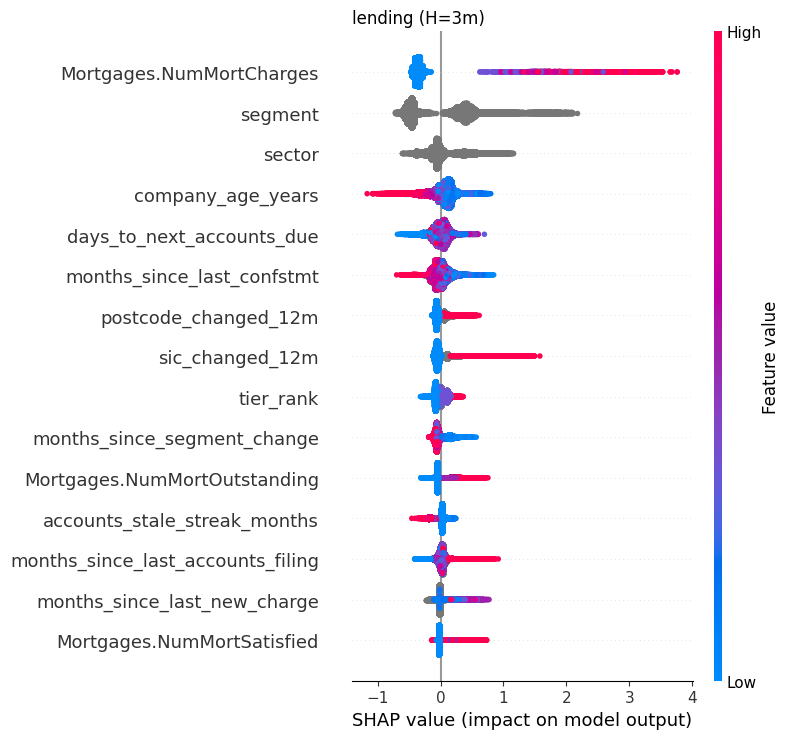

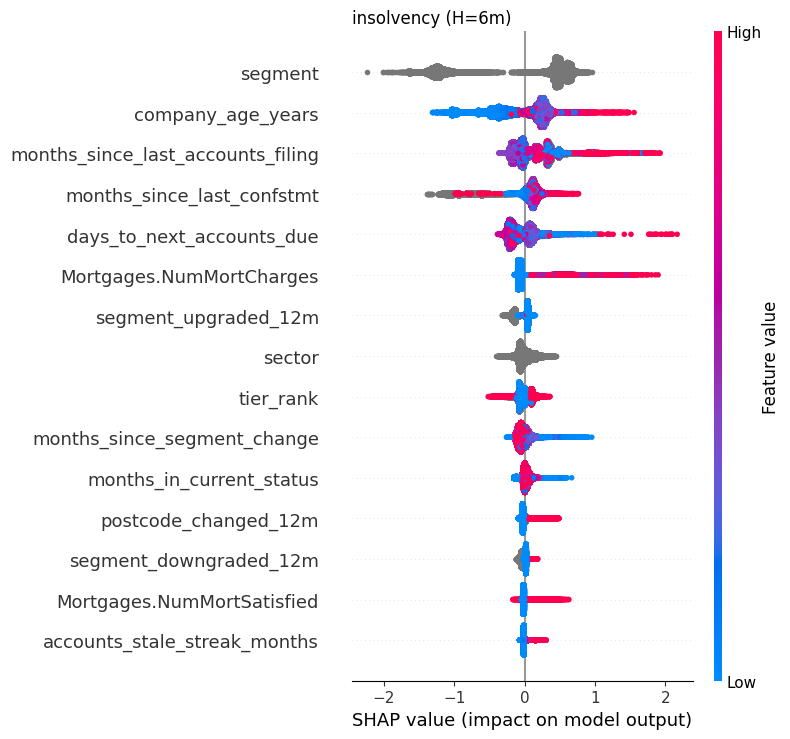

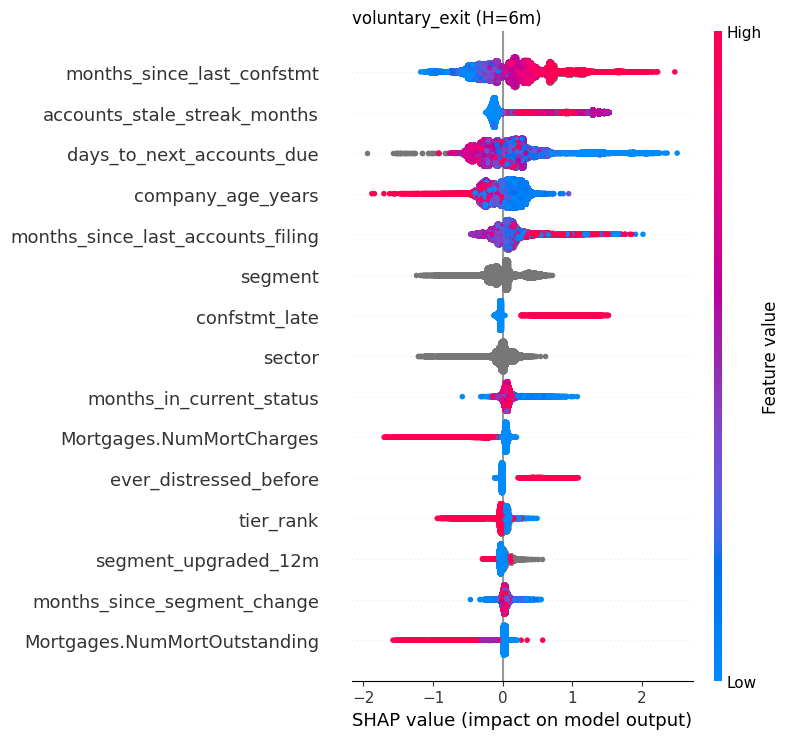

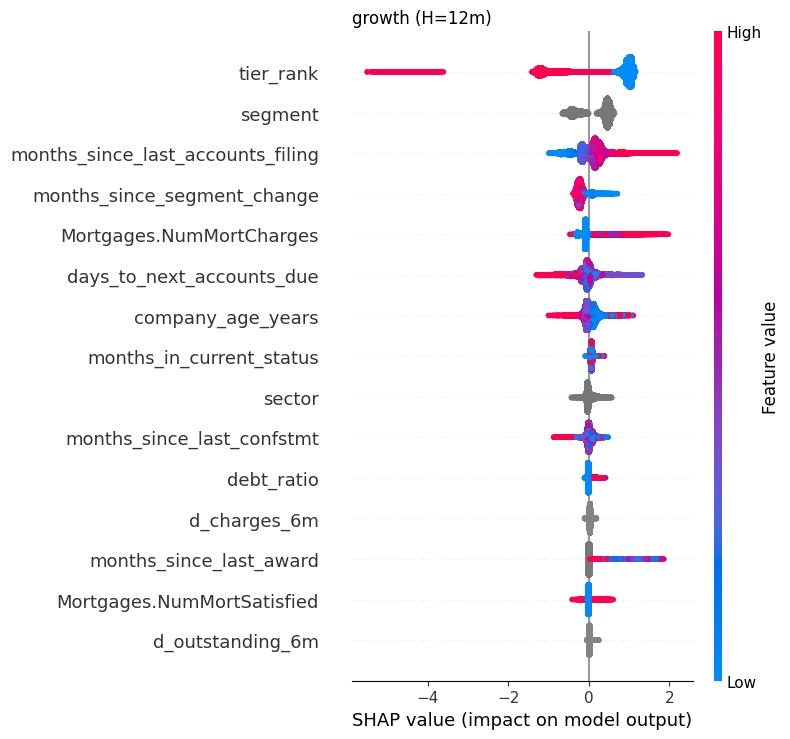

In [12]:
for t, e in explanations.items():
    shap.summary_plot(e["shap"], e["X"], max_display=15, show=False)
    plt.title(f"{t} (H={targets.TARGETS[t][1]}m)", loc="left")
    plt.tight_layout()
    plt.show()

### Does the logistic floor agree with SHAP on direction?

The point of fitting the linear model was not its AUC, it was this. Two independent views of the same
question: does feature X push the prediction up or down. Where they disagree, one of them is wrong and it
is worth knowing which before any of this reaches a relationship manager.

One thing I got wrong on the first pass and am writing down so nobody repeats it: **the mean signed SHAP
value is not a direction.** It is the average contribution across the sample, and for a feature whose
effect is non-monotone (say, both very new and very old companies borrow more) it can average to nearly
anything, including the opposite of the truth. The direction of a feature is the relationship between the
**feature's value and its own SHAP value**, which is what the colour gradient in a summary plot shows. So
that is what I measure, as a Spearman correlation, which does not assume the relationship is linear.

Categoricals are skipped here. `sector` and `segment` one-hot into many coefficients and do not have a
single direction to compare, so asking the question of them is not meaningful.

In [13]:
from scipy.stats import spearmanr


def logit_directions(target, k=12):
    e = explanations[target]
    pipe = results[target]["_models"]["logistic"]
    names = pipe.named_steps["pre"].get_feature_names_out()
    coefs = pd.Series(pipe.named_steps["clf"].coef_[0], index=names)
    cols = list(e["X"].columns)
    out = []
    for row in e["importance"].head(k).itertuples():
        # Drop the imputer's missingness indicators: "was this NULL" is a different
        # question from "which way does the value push", and matching on the suffix
        # alone would happily pick the indicator's coefficient instead. Categoricals
        # match nothing here and fall out, which is the intent.
        hits = coefs[[n for n in names
                      if n.endswith("__" + row.feature) and "missingindicator" not in n]]
        if len(hits) == 0:
            continue
        j = cols.index(row.feature)
        x = e["X"].iloc[:, j].to_numpy(dtype=float)
        ok = ~np.isnan(x)
        if ok.sum() < 1000 or np.nanstd(x[ok]) == 0:
            continue
        rho = float(spearmanr(x[ok], e["shap"][ok, j]).statistic)
        c = float(hits.iloc[int(np.argmax(np.abs(hits.to_numpy())))])
        out.append({"feature": row.feature, "shap_direction": rho, "logit_coef": c,
                    "agree": np.sign(rho) == np.sign(c)})
    return pd.DataFrame(out).assign(target=target)


directions = pd.concat([logit_directions(t) for t in targets.TARGETS], ignore_index=True)
directions.pivot_table(index="target", columns="agree", values="feature",
                       aggfunc="count").fillna(0).astype(int)

agree,False,True
target,,
growth,1,9
insolvency,7,3
lending,2,8
voluntary_exit,1,9


In [14]:
directions[~directions["agree"]][["target", "feature", "shap_direction", "logit_coef"]]

,target,feature,shap_direction,logit_coef
2,lending,days_to_next_accounts_due,0.045162,-0.033939
8,lending,Mortgages.NumMortOutstanding,0.531426,-0.057019
11,insolvency,months_since_last_accounts_filing,0.277126,-0.009965
13,insolvency,days_to_next_accounts_due,-0.354235,0.045659
14,insolvency,Mortgages.NumMortCharges,0.540736,-0.071688
15,insolvency,segment_upgraded_12m,-0.107058,0.013338
16,insolvency,tier_rank,0.682508,-0.165088
17,insolvency,months_since_segment_change,-0.591868,0.061603
18,insolvency,months_in_current_status,0.034938,-0.074507
26,voluntary_exit,months_in_current_status,-0.153001,0.071298


Disagreements are not automatically a bug. The logistic coefficient is a *partial* effect holding every
other feature fixed, and with features as correlated as these (`d_charges_3m`, `d_charges_6m` and
`d_charges_12m` measure overlapping windows of the same thing) a partial effect can legitimately flip sign
against the marginal relationship SHAP is showing. What the table is for is spotting a feature where the
two disagree *and* the SHAP direction is economically implausible. That is the one to go and look at.

## Score the live month

Score wide and cheap, enrich narrow and expensive. Every active company in the latest panel month gets a
recalibrated probability from each of the four models; only the top few hundred are ever worth spending a
Companies House API call on.

Two caveats that belong on the output rather than in my head.

**The contract features in this month are past the harvest watermark.** The two OCDS bulk files refresh on
different cadences, so contract counts in the final month or two fall because we stopped observing, not
because companies stopped winning work. Fine to score on, not fine to train on, which is why
`targets._check_contract_watermark` refuses the latter.

**These are prospect scores, not decisions.** A high insolvency score is a reason to look, not a reason to
decline.

In [15]:
%%time
live = train.load_scoring_frame()
# The live month need not contain every sector/segment level the models saw, and
# category codes are positional. Pin them to the training levels before predicting.
train.apply_categories(live, results["lending"]["_X_test"])
print(f"{len(live):,} active companies at {panel.LAST_MONTH}")

for t, r in results.items():
    live[f"score_{t}"] = train.score_frame(
        r["_models"]["lightgbm"], live, r["calibration"]["train_neg_keep_rate"])

live[[f"score_{t}" for t in targets.TARGETS]].describe().T.style.format("{:.4%}")

1,409,284 active companies at 2026-07-01


CPU times: user 2min 59s, sys: 3.15 s, total: 3min 2s
Wall time: 34.8 s


,count,mean,std,min,25%,50%,75%,max
score_lending,140928400.0000%,0.2953%,1.1170%,0.0051%,0.0374%,0.0702%,0.1415%,57.7182%
score_insolvency,140928400.0000%,0.3816%,0.6449%,0.0037%,0.0593%,0.2730%,0.4435%,47.7896%
score_voluntary_exit,140928400.0000%,9.4086%,13.8496%,0.0001%,2.8113%,4.3769%,8.1341%,92.4460%
score_growth,140928400.0000%,2.6652%,2.1435%,0.0017%,0.6686%,2.6919%,4.0241%,52.4437%


The means sit on the labelled base rates, which is the calibration check surviving contact with a month
the models have never seen. That is about as good a smoke test of the whole pipeline as I have.

In [16]:
def top_prospects(target, n=10):
    cols = ["CompanyNumber", "CompanyName", f"score_{target}", "segment", "sector",
            "Mortgages.NumMortCharges", "new_charge_events_12m", "accounts_overdue_streak_months"]
    return (live.nlargest(n, f"score_{target}")[cols]
                .rename(columns={f"score_{target}": "score"})
                .assign(target=target))

pd.concat([top_prospects(t, 5) for t in targets.TARGETS], ignore_index=True)

,CompanyNumber,CompanyName,score,segment,sector,Mortgages.NumMortCharges,new_charge_events_12m,accounts_overdue_streak_months,target
0,12723324,MS LENDING GROUP LIMITED,0.577182,Large,Fast growth & emerging,578.0,11.0,0.0,lending
1,11731838,COHORT CAPITAL LTD,0.575891,Large,Fast growth & emerging,92.0,11.0,0.0,lending
2,03188994,CASTLE AIR LIMITED,0.531888,Large,Manufacturing,94.0,4.0,0.0,lending
3,01581476,PROUDREED LIMITED,0.525672,Large,"Technology, legal & professional",49.0,3.0,0.0,lending
4,03094287,T M TRUSTEES LIMITED,0.524862,Dormant,Fast growth & emerging,684.0,10.0,0.0,lending
5,09654369,APOIDEA SOLUTIONS LIMITED,0.477896,Micro,"Technology, legal & professional",0.0,0.0,0.0,insolvency
6,05144979,SPIDERWEBSITES LIMITED,0.477327,Micro,Fast growth & emerging,0.0,0.0,0.0,insolvency
7,12705598,"MUMANIELA PROJECT, ART AND DESING LTD",0.457941,Micro,"Technology, legal & professional",0.0,0.0,0.0,insolvency
8,07296415,CAPITALINVEST HOLDING LTD,0.445262,Micro,"Technology, legal & professional",0.0,0.0,0.0,insolvency
9,12066662,SIGPROC LTD,0.443755,Micro,Fast growth & emerging,0.0,0.0,0.0,insolvency


In [17]:
SCORE_PATH = train.SCORE_DIR / f"scores_{pd.Timestamp(panel.LAST_MONTH):%Y-%m}.parquet"
train.SCORE_DIR.mkdir(parents=True, exist_ok=True)
live[["CompanyNumber", "CompanyName", "origin_month",
      *[f"score_{t}" for t in targets.TARGETS]]].to_parquet(SCORE_PATH, index=False)
print(f"wrote {SCORE_PATH} ({SCORE_PATH.stat().st_size / 1e6:.1f} MB)")

wrote data/processed/scores/scores_2026-07.parquet (66.0 MB)


## Record the baseline

This is the whole reason for running before the lender harvest finishes. Everything above goes to
`reports/step6/`, which is where every artefact this notebook produces now lives: the metrics under the
tag `baseline`, keyed by target and carrying the exact `FEATURE_COLS` they were trained on, and one SHAP
importance table per target beside them. They only mean anything as a set, so they may as well sit
together.

When the Charges API harvest lands and `targets.FEATURE_COLS` grows, re-running this notebook writes a
second tag into the same JSON and a second set of `shap_importance_<tag>_<target>.csv` next to these ones.
The comparison is then a diff rather than a memory.


In [18]:
path = train.save_results(
    list(results.values()),
    tag="baseline",
    grouped_cv=cv.to_dict("records"),
    direction_check=directions.to_dict("records"),
)
print(path)

for t, e in explanations.items():
    out = train.shap_importance_path(t, tag="baseline")
    e["importance"].to_csv(out, index=False)
    print(out)


reports/step6/model_results.json
reports/step6/shap_importance_baseline_lending.csv
reports/step6/shap_importance_baseline_insolvency.csv
reports/step6/shap_importance_baseline_voluntary_exit.csv
reports/step6/shap_importance_baseline_growth.csv


## What I would do next, in order

1. **Nothing about hyperparameters.** Tuning against a feature set that is about to gain columns is wasted
   effort. Tune once, at the end, on the final matrix.
2. **The strict versus extended contract A/B.** Already set up in step 4b: two directories, identical
   schema, a one-line switch (`contracts_dir=contracts.ASOF_EXT_DIR`). Rebuild the matrices against the
   name-matched set and compare out-of-time AUC against the numbers above. My guess is it helps lending
   and does nothing for insolvency, but that is a prediction to test, and now there is something to test it
   against.
3. **The lender features, when the harvest lands.** Same comparison, same file, different tag. Because
   step 6 reads `targets.FEATURE_COLS` rather than a copy of it, adding columns is a zero-line change here.
4. **The composite indices.** This is the real deliverable: the model scores become **Lending Readiness**,
   **Credit Risk Exposure** and **Growth Signal**, with per-company SHAP reasons attached, so the output is
   "this company, this score, and here are the three things driving it" rather than an unexplained number.
   The scores parquet written above plus `explanations` is everything that needs.